In [ ]:
#!pip install opencv_python matplotlib

In [ ]:
import xml.etree.ElementTree as ET
import os
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import numpy as np
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader

In [ ]:
#for download from kagel
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/face-mask-detection")

print("Path to dataset files:", path)

100%|██████████| 398M/398M [00:23<00:00, 17.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/andrewmvd/face-mask-detection/versions/1


In [ ]:
#این تابع رو مینویسم برای اینکه بتونیم هر فایل xml رو بتونیم تجزیه کنیم واطلاعات لازممون رو ازش بکشیم بیرون
def parse_xml_annotation(Xml_dir:str):
    tree=ET.parse(Xml_dir)
    root=tree.getroot()


    labels=[]
    bndboxes=[]

    for obj in root.findall("object"):
        labels.append(obj.findtext("name"))
        x_min=int(obj.find("bndbox").findtext("xmin"))
        y_min=int(obj.find("bndbox").findtext("ymin"))
        x_max=int(obj.find("bndbox").findtext("xmax"))
        y_max=int(obj.find("bndbox").findtext("ymax"))
        bndboxes.append([x_min,y_min,x_max,y_max])

    return labels,bndboxes




In [ ]:
#تست برای بررسی درست کار کردن تابع
xml_file_path =os.path.join(path,"./annotations/maksssksksss0.xml")
l,b = parse_xml_annotation(xml_file_path)
print("Boxes:", b)
print("Labels:", l)

Boxes: [[79, 105, 109, 142], [185, 100, 226, 144], [325, 90, 360, 141]]
Labels: ['without_mask', 'with_mask', 'without_mask']


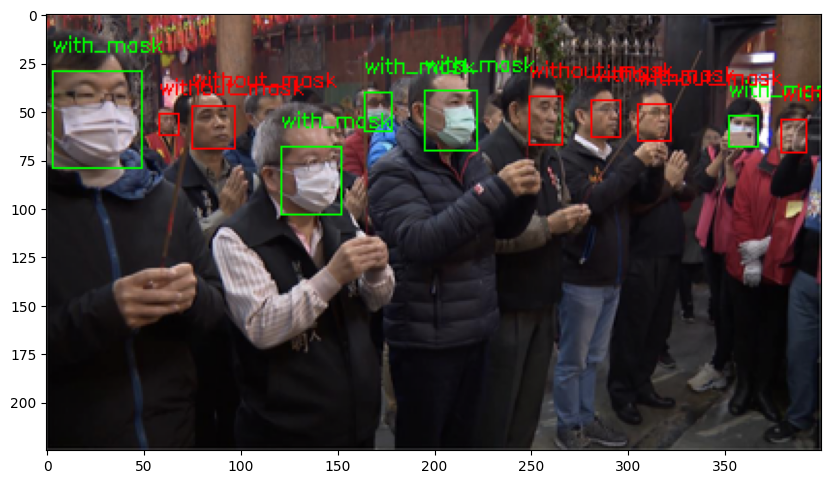

In [ ]:

def visualize_sample(image_path,xml_path):
    image=cv2.imread(image_path)
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    labels ,boxes=parse_xml_annotation(xml_path)
    for i in range(len(labels)):

        if labels[i]=="without_mask":
            color=(255,0,0)
        elif labels[i]=="with_mask":
            color=(0,255,0)
        else:
            color=(255,255,0)

        cv2.rectangle(image,(boxes[i][0],boxes[i][1]),(boxes[i][2],boxes[i][3]),color,1)
        cv2.putText(image,labels[i],(boxes[i][0], boxes[i][1] - 10), cv2.FONT_HERSHEY_SIMPLEX,0.35,color,1)
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    plt.show()

xml_path=os.path.join(path,"annotations","maksssksksss735.xml")
img_path=os.path.join(path,"images","maksssksksss735.png")
visualize_sample(img_path,xml_path)

In [ ]:
import torch
from torch.utils.data import Dataset
import os
import cv2
import numpy as np
# تابعی که مرحله قبل نوشتیم رو اینجا نیاز داریم، پس یا ایمپورتش کن یا بذار بالای این کد باشه

class FaceMaskDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(os.path.join(root_dir, "images"))))
        self.annotations = list(sorted(os.listdir(os.path.join(root_dir, "annotations"))))

        # دیکشنری تبدیل متن به عدد
        self.class_map = {
            'with_mask': 1,
            'without_mask': 2,
            'mask_weared_incorrect': 3
        }

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # 1. مسیر فایل عکس و XML
        img_path = os.path.join(self.root_dir, "images", self.imgs[idx])
        ann_path = os.path.join(self.root_dir, "annotations", self.annotations[idx])

        # 2. خواندن تصویر
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # تبدیل به RGB

        # نرمال‌سازی ساده (تبدیل پیکسل‌ها به بازه 0 تا 1)
        img = img.astype(np.float32) / 255.0

        # 3. خواندن باکس‌ها و لیبل‌ها (با استفاده از تابعی که قبلاً نوشتیم)
        labels_text, boxes_list = parse_xml_annotation(ann_path)

        boxes = []
        labels = []

        for i in range(len(boxes_list)):
            # تبدیل متن کلاس به عدد
            label_text = labels_text[i]
            label_idx = self.class_map[label_text]

            # مختصات باکس
            xmin, ymin, xmax, ymax = boxes_list[i]
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label_idx)

        # 4. تبدیل به Tensor (فرمت مورد نیاز PyTorch)
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        # محاسبه مساحت باکس‌ها (بعضی مدل‌ها نیاز دارند)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64) # فرض می‌کنیم crowd نداریم

        # دیکشنری نهایی که هدف (Target) ماست
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])
        target["area"] = area
        target["iscrowd"] = iscrowd

        # نکته: تصویر باید فرمتش (Channel, Height, Width) باشه
        # الان (Height, Width, Channel) هست. پس جابجاش می‌کنیم:
        img = torch.tensor(img).permute(2, 0, 1)

        if self.transforms:
            # اینجا بعداً می‌تونیم تغییراتی روی عکس بدیم (Data Augmentation)
            pass

        return img, target

In [ ]:
# مسیر اصلی دیتاست خودت رو اینجا بده
root_dataset_path = path

# ساخت یک نمونه از دیتاست
dataset = FaceMaskDataset(root_dataset_path)

# گرفتن اولین داده
img, target = dataset[0]

print("Image Shape:", img.shape)
# باید بشه: torch.Size([3, ارتفاع, عرض])

print("Target Boxes:", target['boxes'])
# باید یک تنسور ببینی با مختصات باکس‌ها

print("Target Labels:", target['labels'])
# باید اعداد 1، 2 یا 3 رو ببینی

Image Shape: torch.Size([3, 366, 512])
Target Boxes: tensor([[ 79., 105., 109., 142.],
        [185., 100., 226., 144.],
        [325.,  90., 360., 141.]])
Target Labels: tensor([2, 1, 2])


In [ ]:
def get_model_instance_segmentation(num_classes:int):
    model=torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(pretrained=True)

    num_input=model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor=FastRCNNPredictor(num_input,num_classes)

    return model


In [ ]:
def collate_fn(bath):
    return tuple(zip(*bath))

dataset=FaceMaskDataset(path)

indices = torch.randperm(len(dataset)).tolist()
dataset_train = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset, indices[-50:])

train_data_loader=DataLoader(
    dataset_train,
    batch_size=2, # Reduced batch size to mitigate OOM
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

test_data_loader=DataLoader(
    dataset_test,
    batch_size=1, # Reduced batch size to mitigate OOM
    collate_fn=collate_fn
)

In [ ]:
# 1. ساخت مدل (4 کلاس: 0-background, 1-mask, 2-no_mask, 3-incorrect)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
num_classes = 4
model = get_model_instance_segmentation(num_classes)
model.to(device) # مدل رو بفرست روی کارت گرافیک (اگر داری)

# 2. گرفتن یک بچ از داده‌ها
images, targets = next(iter(train_data_loader))

# 3. انتقال داده‌ها به دستگاه (GPU یا CPU)
images = list(image.to(device) for image in images)
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

# 4. اجرای مدل (فقط تست)
# وقتی مدل در حالت train باشه، خروجی‌ش Loss (میزان خطا) هست
output = model(images, targets)

print("Output Keys (Losses):")
for key, value in output.items():
    print(f"{key}: {value.item()}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 203MB/s]


Output Keys (Losses):
loss_classifier: 1.5756436586380005
loss_box_reg: 0.2618783116340637
loss_objectness: 0.015531823970377445
loss_rpn_box_reg: 0.020131904631853104


In [ ]:
import torch.optim as optim
import time
import torch.cuda.amp as amp # Import Automatic Mixed Precision

# --- 1. تنظیمات اولیه ---
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Training on: {device}")

# مدل رو دوباره میسازیم که مطمئن باشیم ترتمیزه
num_classes = 4
model = get_model_instance_segmentation(num_classes)
model.to(device)

# تعریف بهینه‌ساز (Optimizer)
# پارامترها: lr (نرخ یادگیری)، momentum، weight_decay (برای جلوگیری از Overfitting)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# Initialize GradScaler for mixed precision training
scaler = amp.GradScaler()

# تنظیم تعداد دورهای آموزش (Epochs)
# چون دیتاست کوچیکه، ۱۰ دور معمولاً کافیه. اگر GPU نداری، ۵ تا بذار تست کنی.
num_epochs = 20

# --- 2. حلقه اصلی آموزش ---
for epoch in range(num_epochs):
    print(f"Starting Epoch {epoch+1}/{num_epochs}")
    start_time = time.time()

    model.train() # مدل رو به حالت آموزش می‌بریم
    epoch_loss = 0 # جمع خطاها در این دور

    i = 0
    for images, targets in train_data_loader:
        # انتقال داده‌ها به GPU/CPU
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Zero the gradients explicitly at the start of each batch
        optimizer.zero_grad()

        # Use autocast for mixed precision
        with amp.autocast():
            # محاسبه خطا (Loss)
            loss_dict = model(images, targets)

            # جمع زدن تمام خطاهای مختلف (خطای کلاس + خطای مختصات باکس + ...)
            losses = sum(loss for loss in loss_dict.values())

        # Backpropagate using the scaler
        scaler.scale(losses).backward()

        # Optimizer step using the scaler
        scaler.step(optimizer)

        # Update the scaler for the next iteration
        scaler.update()

        epoch_loss += losses.item()

        if i % 10 == 0: # هر ۱۰ بچ یکبار پرینت کن که بدونیم زنده‌ست
            print(f"  Batch {i}: Loss = {losses.item():.4f}")
        i += 1

    end_time = time.time()
    print(f"Epoch {epoch+1} done in {end_time - start_time:.1f}s | Average Loss: {epoch_loss/len(train_data_loader):.4f}")
    print("-" * 30)

print("Training Finished! 🎉")

# --- 3. ذخیره مدل (اختیاری ولی توصیه میشه) ---
torch.save(model.state_dict(), 'mask_detector_model.pth')
print("Model saved as mask_detector_model.pth")

Training on: cuda


/tmp/ipykernel_1920/111763187.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/tmp/ipykernel_1920/111763187.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Starting Epoch 1/20
  Batch 0: Loss = 1.8130
  Batch 10: Loss = 1.1472
  Batch 20: Loss = 0.6807
  Batch 30: Loss = 0.2943
  Batch 40: Loss = 0.7139
  Batch 50: Loss = 0.8519
  Batch 60: Loss = 0.8216
  Batch 70: Loss = 0.3877
  Batch 80: Loss = 0.3079
  Batch 90: Loss = 0.1898
  Batch 100: Loss = 0.1202
  Batch 110: Loss = 0.5164
  Batch 120: Loss = 0.5061
  Batch 130: Loss = 0.2067
  Batch 140: Loss = 0.4036
  Batch 150: Loss = 0.3475
  Batch 160: Loss = 0.1119
  Batch 170: Loss = 0.1444
  Batch 180: Loss = 0.3199
  Batch 190: Loss = 0.2564
  Batch 200: Loss = 0.3677
  Batch 210: Loss = 0.3798
  Batch 220: Loss = 0.3689
  Batch 230: Loss = 0.1007
  Batch 240: Loss = 0.4461
  Batch 250: Loss = 0.1436
  Batch 260: Loss = 0.0658
  Batch 270: Loss = 0.0869
  Batch 280: Loss = 0.0561
  Batch 290: Loss = 0.4537
  Batch 300: Loss = 0.4548
  Batch 310: Loss = 0.2452
  Batch 320: Loss = 0.4564
  Batch 330: Loss = 0.1284
  Batch 340: Loss = 0.4753
  Batch 350: Loss = 0.2399
  Batch 360: Loss =

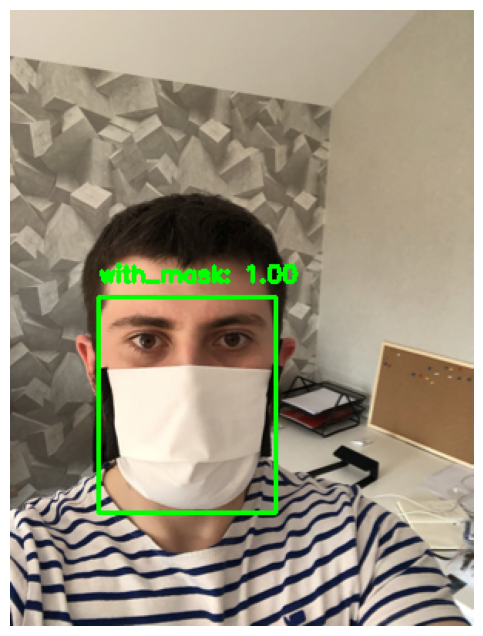

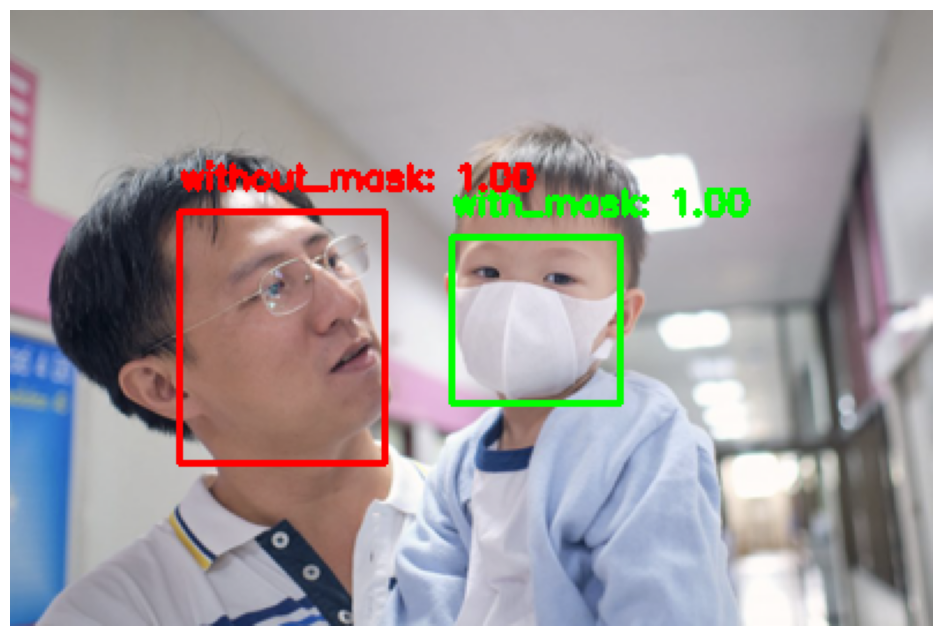

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# دیکشنری برای تبدیل عدد به متن (برعکس قبلی)
id_to_class = {
    1: 'with_mask',
    2: 'without_mask',
    3: 'mask_weared_incorrect'
}

def predict_and_plot(model, img_tensor, device, threshold=0.5):
    """
    img_tensor: عکس تکی که تبدیل به تنسور شده
    threshold: حداقل امتیازی که قبول می‌کنیم (مثلاً بالای 50 درصد اطمینان)
    """
    # 1. آماده‌سازی مدل برای تست
    model.eval()
    img_tensor = img_tensor.to(device)

    # 2. پیش‌بینی
    with torch.no_grad(): # گرادیان لازم نداریم
        prediction = model([img_tensor])[0] # خروجی اولین عکس رو می‌گیریم

    # 3. تبدیل تصویر برای نمایش (از تنسور به فرمت numpy تصویر)
    img_display = img_tensor.cpu().permute(1, 2, 0).numpy().copy() # (C,H,W) -> (H,W,C)

    # چون تصویر نرمال شده (0 تا 1)، برای نمایش با cv2 برمی‌گردونیم به 0 تا 255
    # ولی matplotlib با 0-1 هم کار میکنه، اما برای cv2 بهتره کانورت بشه
    img_display = cv2.cvtColor(img_display, cv2.COLOR_RGB2BGR)

    # 4. فیلتر کردن نتایج
    boxes = prediction['boxes'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()

    # کشیدن باکس‌ها
    for i, score in enumerate(scores):
        if score > threshold: # فقط اونایی که مطمئنه
            box = boxes[i].astype(int)
            label_id = labels[i]
            label_text = id_to_class.get(label_id, 'Unknown')

            # تنظیم رنگ (سبز: با ماسک، قرمز: بی ماسک، زرد: غلط)
            if label_id == 1: color = (0, 255, 0)
            elif label_id == 2: color = (0, 0, 255) # توی OpenCV قرمز اینجاست BGR
            else: color = (0, 255, 255)

            # رسم مستطیل
            cv2.rectangle(img_display, (box[0], box[1]), (box[2], box[3]), color, 2)

            # نوشتن متن + امتیاز اطمینان
            text = f"{label_text}: {score:.2f}"
            cv2.putText(img_display, text, (box[0], box[1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # نمایش نهایی
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB) # برای matplotlib
    plt.figure(figsize=(12, 8))
    plt.imshow(img_display)
    plt.axis('off')
    plt.show()

# --- اجرا روی چند تا از عکس‌های تست ---
# عکس شماره 2 از دیتاست تست رو انتخاب می‌کنیم
img_tensor, target = dataset_test[2]
predict_and_plot(model, img_tensor, device, threshold=0.6)

# عکس شماره 10
img_tensor, target = dataset_test[10]
predict_and_plot(model, img_tensor, device, threshold=0.6)